--- Train set metrics ---
RMSE: 0.23
MAE: 0.18
R²: 0.945

--- Test set metrics ---
RMSE: 0.25
MAE: 0.19
R²: 0.938

 We have saved the regression model as: 'ridge_monthlyincome_model.joblib'


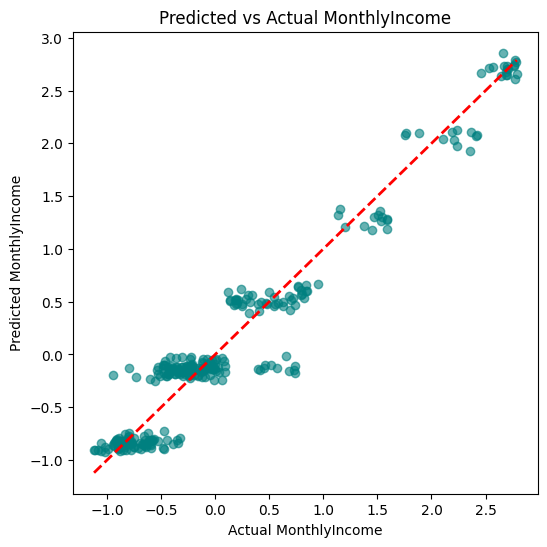

5-fold CV R² scores: [0.93437986 0.91684543 0.94965385 0.95156403 0.94402263]
Mean CV R²: 0.939


In [6]:
# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# --- Load processed dataset ---
df = pd.read_csv("../data/processed_hr_dataset.csv")

# --- Define target and features ---
X = df.drop(columns=["MonthlyIncome"])
y = df["MonthlyIncome"]

# --- Split into train and test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


numeric_features = ["Age", "DailyRate", "DistanceFromHome", "YearsAtCompany",
                    "YearsInCurrentRole", "TotalWorkingYears", "JobLevel",
                    "StockOptionLevel", "TrainingTimesLastYear", "NumCompaniesWorked"]

scaler_reg = StandardScaler()
X_train[numeric_features] = scaler_reg.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler_reg.transform(X_test[numeric_features])

# Gem scaleren til senere
joblib.dump(scaler_reg, "../models/scaler_for_regression.joblib")
# --- Save feature names for later use in app ---
joblib.dump(X_train.columns, "../models/regression_feature_names.joblib")

# --- Train Ridge Regression model ---
ridge = Ridge(alpha=1.0)  # regularization parameter
ridge.fit(X_train, y_train)

# --- Predict on train and test sets ---
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

# --- Evaluate model ---
def regression_metrics(y_true, y_pred, dataset=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {dataset} set metrics ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.3f}\n")

regression_metrics(y_train, y_train_pred, "Train")
regression_metrics(y_test, y_test_pred, "Test")

# --- Save the trained model for later ---
joblib.dump(ridge, "../models/ridge_monthlyincome_model.joblib")
print(" We have saved the regression model as: 'ridge_monthlyincome_model.joblib'")
# --- Plot predicted vs actual (test set) ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual MonthlyIncome")
plt.ylabel("Predicted MonthlyIncome")
plt.title("Predicted vs Actual MonthlyIncome")
plt.show()

# Optional: k-fold cross-validation on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ridge, X_train, y_train, cv=kf, scoring='r2')
print(f"5-fold CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.3f}")